# QR-Based EMNIST Letter Classification with Incremental QR Updates

This notebook implements a nearest-subspace classifier for EMNIST Letters and
studies how a QR factorization can be updated when new training columns are
appended.

## Contents

1. Load and prepare EMNIST Letters
2. Compute full QR factors with Householder reflections
3. Baseline nearest-subspace classification
4. Implement the Hammarling–Lucas Givens convention
5. Validate the QR update on small random matrices
6. Append 20 training samples per class using incremental QR updates
7. Validate reconstruction, orthogonality, upper-trapezoidal structure, and a NumPy QR reference
8. Compare update runtime with full recomputation
9. Re-run classification after the update
10. Limitations and reference

> **Reference used for the update convention:**  
> Sven Hammarling and Craig Lucas, *Updating the QR Factorization and the Least
> Squares Problem*, MIMS EPrint 2008.111, University of Manchester, 2008.
> This notebook follows Algorithm 1.1 for the Givens convention and specializes
> the column-addition logic of Algorithms 2.19–2.20 to the case where new
> columns are appended at the end.


In [1]:
import time
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from torchvision import transforms

np.set_printoptions(precision=4, suppress=True)


## 1. Load and prepare the EMNIST Letters data

Each image is flattened from \(28\times 28\) to a 784-dimensional vector.
For every class A–Z, the baseline experiment uses 200 training samples and
20 test samples. Later, the next 20 training samples per class are appended,
giving 220 training columns per class.


In [2]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.EMNIST(
    root="./data",
    split="letters",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = torchvision.datasets.EMNIST(
    root="./data",
    split="letters",
    train=False,
    download=True,
    transform=transform,
)

def extract_balanced_subset(dataset, samples_per_class):
    """Return the first `samples_per_class` samples for each EMNIST letter."""
    class_data = defaultdict(list)

    for image, label in dataset:
        if len(class_data[label]) < samples_per_class:
            class_data[label].append(image.reshape(-1))

        if all(len(class_data[i]) >= samples_per_class for i in range(1, 27)):
            break

    return class_data

train_data_per_class = extract_balanced_subset(train_dataset, 200)
test_data_per_class = extract_balanced_subset(test_dataset, 20)

A_matrices = {
    label: torch.stack(train_data_per_class[label], dim=1)
    for label in range(1, 27)
}

test_vectors = []
test_labels = []

for label in range(1, 27):
    for image in test_data_per_class[label]:
        test_vectors.append(image)
        test_labels.append(label)

test_vectors = torch.stack(test_vectors)
test_labels = torch.tensor(test_labels)

# Use float64 for the numerical-linear-algebra part.
A_matrices_np = {
    label: matrix.numpy().astype(np.float64, copy=False)
    for label, matrix in A_matrices.items()
}
test_vectors_np = test_vectors.numpy().astype(np.float64, copy=False)
test_labels_np = test_labels.numpy()

print("Data preparation completed.")
print("A_1 shape:", A_matrices_np[1].shape)
print("One test vector shape:", test_vectors_np[0].shape)
print("Total test samples:", len(test_labels_np))


Data preparation completed.
A_1 shape: (784, 200)
One test vector shape: (784,)
Total test samples: 520


## 2. Householder QR decomposition

The project forms the full \(m\times m\) orthogonal factor \(Q\), because the
incremental update explicitly applies rotations to columns of \(Q\).

The implementation below uses rank-1 Householder updates instead of constructing
a full Householder matrix at every step. It also includes the missing zero-norm
guard: if the active column segment is already zero, the reflection is skipped.

This is intentionally a **full-Q educational implementation**. For
\(m=784\), one float64 \(Q\) matrix uses about 4.69 MiB, so 26 cached \(Q\)
matrices alone use about 122 MiB. A production implementation would normally
prefer a factored or economy representation when possible.


In [3]:
def householder_qr(A):
    """
    Compute a full QR factorization A = Q @ R with Householder reflections.

    Parameters
    ----------
    A : array_like, shape (m, n)

    Returns
    -------
    Q : ndarray, shape (m, m)
        Orthogonal matrix.
    R : ndarray, shape (m, n)
        Upper-trapezoidal factor.
    """
    A = np.asarray(A, dtype=np.float64)
    m, n = A.shape

    R = A.copy()
    Q = np.eye(m, dtype=np.float64)

    for k in range(min(m, n)):
        x = R[k:, k]
        norm_x = np.linalg.norm(x)

        # Zero-norm guard: no reflection is needed.
        if norm_x == 0.0:
            continue

        # Stable sign choice avoids cancellation in the first component.
        v = x.copy()
        sign = 1.0 if x[0] >= 0.0 else -1.0
        v[0] += sign * norm_x

        norm_v = np.linalg.norm(v)
        if norm_v == 0.0:
            continue

        v /= norm_v

        # H = I - 2 v v^T, applied only to the active blocks.
        R[k:, k:] -= 2.0 * np.outer(v, v @ R[k:, k:])
        Q[:, k:] -= 2.0 * np.outer(Q[:, k:] @ v, v)

        # Enforce the intended structural zeros explicitly.
        R[k + 1 :, k] = 0.0

    return Q, R


In [4]:
def qr_factorization_errors(A, Q, R):
    """Return relative reconstruction, orthogonality, and triangularity errors."""
    m = Q.shape[0]
    eps = np.finfo(float).eps

    reconstruction = np.linalg.norm(A - Q @ R, ord="fro") / max(
        np.linalg.norm(A, ord="fro"), eps
    )
    orthogonality = np.linalg.norm(Q.T @ Q - np.eye(m), ord="fro") / np.sqrt(m)
    triangularity = np.linalg.norm(np.tril(R, k=-1), ord="fro") / max(
        np.linalg.norm(R, ord="fro"), eps
    )

    return reconstruction, orthogonality, triangularity


qr_cache = {}
initial_validation = []

start = time.perf_counter()

for label in range(1, 27):
    A = A_matrices_np[label]
    Q, R = householder_qr(A)
    qr_cache[label] = (Q, R)

    rec_err, orth_err, tri_err = qr_factorization_errors(A, Q, R)
    initial_validation.append(
        {
            "Label": label,
            "Reconstruction": rec_err,
            "Orthogonality": orth_err,
            "Triangularity": tri_err,
        }
    )

initial_qr_time = time.perf_counter() - start
initial_validation_df = pd.DataFrame(initial_validation)

print(f"Built 26 full QR factorizations in {initial_qr_time:.3f} s")
print("\nWorst initial-factorization errors:")
print(initial_validation_df[["Reconstruction", "Orthogonality", "Triangularity"]].max())


Built 26 full QR factorizations in 3.423 s

Worst initial-factorization errors:
Reconstruction    1.026691e-15
Orthogonality     1.278152e-15
Triangularity     0.000000e+00
dtype: float64


## 3. Baseline nearest-subspace classification

For each class, the least-squares residual is computed in QR coordinates.
Because \(Q\) is orthogonal,

\[
\|z-Ax\|_2 = \|Q^Tz-Rx\|_2.
\]

All test right-hand sides for one class are solved in one call. This avoids
reconstructing \(A=QR\) inside the prediction loop.


In [5]:
def classify_with_qr_cache(qr_cache, test_vectors):
    """
    Classify test vectors by the smallest QR least-squares residual.

    Returns
    -------
    predicted_labels : ndarray, shape (n_samples,)
    residual_matrix : ndarray, shape (26, n_samples)
    """
    Z = np.asarray(test_vectors, dtype=np.float64).T
    residual_matrix = np.empty((26, Z.shape[1]), dtype=np.float64)

    for label in range(1, 27):
        Q, R = qr_cache[label]
        Y = Q.T @ Z

        # Multiple right-hand sides in a single least-squares solve.
        coefficients = np.linalg.lstsq(R, Y, rcond=None)[0]
        residual_matrix[label - 1] = np.linalg.norm(
            Y - R @ coefficients, axis=0
        )

    predicted_labels = np.argmin(residual_matrix, axis=0) + 1
    return predicted_labels, residual_matrix


predicted_labels, baseline_residuals = classify_with_qr_cache(
    qr_cache, test_vectors_np
)

accuracy = np.mean(predicted_labels == test_labels_np)
print(f"Baseline classification accuracy: {accuracy * 100:.2f}%")

for i in range(10):
    print(
        f"Test #{i}: true={test_labels_np[i]}, "
        f"predicted={predicted_labels[i]}"
    )


Baseline classification accuracy: 70.58%
Test #0: true=1, predicted=1
Test #1: true=1, predicted=1
Test #2: true=1, predicted=1
Test #3: true=1, predicted=21
Test #4: true=1, predicted=1
Test #5: true=1, predicted=1
Test #6: true=1, predicted=1
Test #7: true=1, predicted=1
Test #8: true=1, predicted=1
Test #9: true=1, predicted=1


,Class,Label,Accuracy
0,A,1,0.75
1,B,2,0.70
2,C,3,0.65
3,D,4,0.40
4,E,5,0.75
5,F,6,0.50
6,G,7,0.55
7,H,8,0.65
8,I,9,0.85
9,J,10,0.60


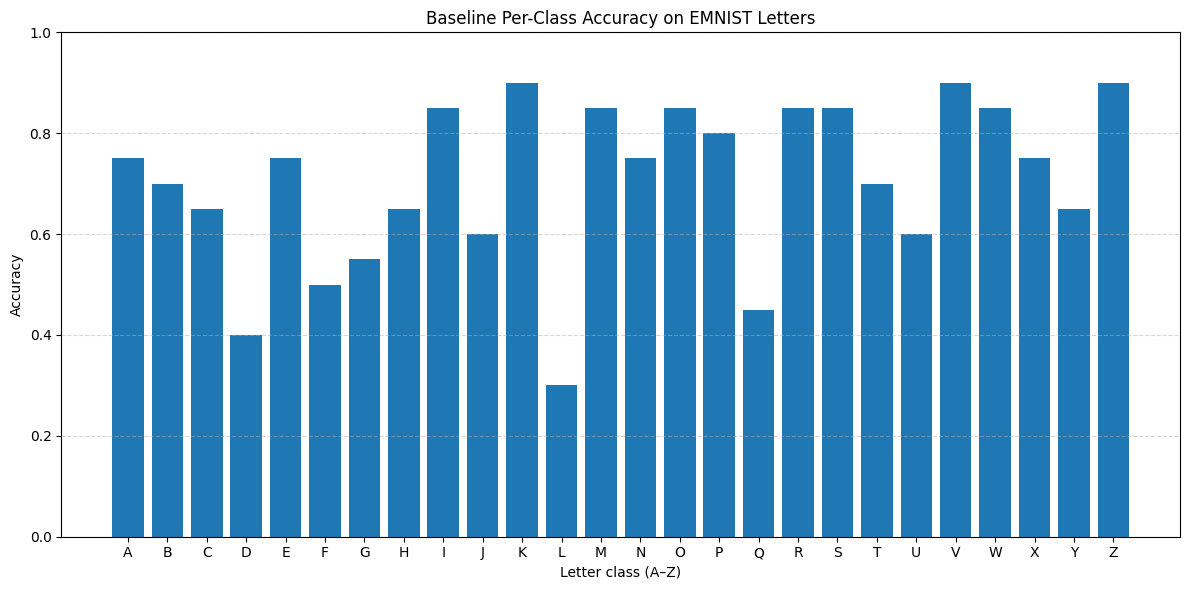

In [6]:
letters = [chr(ord("A") + i) for i in range(26)]

baseline_per_class = []
for label in range(1, 27):
    mask = test_labels_np == label
    baseline_per_class.append(
        np.mean(predicted_labels[mask] == label)
    )

baseline_results_df = pd.DataFrame(
    {
        "Class": letters,
        "Label": np.arange(1, 27),
        "Accuracy": baseline_per_class,
    }
)

display(baseline_results_df)

plt.figure(figsize=(12, 6))
plt.bar(letters, baseline_per_class)
plt.ylim(0, 1)
plt.xlabel("Letter class (A–Z)")
plt.ylabel("Accuracy")
plt.title("Baseline Per-Class Accuracy on EMNIST Letters")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## 4. Givens convention used for the QR update

Hammarling and Lucas define

\[
G =
\begin{bmatrix}
c & s\\
-s & c
\end{bmatrix}
\]

and Algorithm 1.1 returns \(c,s\) such that

\[
G^T
\begin{bmatrix}
a\\b
\end{bmatrix}
=
\begin{bmatrix}
d\\0
\end{bmatrix}.
\]

This distinction is critical. With this convention, the factor update uses

- \(R_{\text{new}} \leftarrow G^T R\) on the affected rows, and
- \(Q_{\text{new}} \leftarrow QG\) on the corresponding columns,

so that \(Q_{\text{new}}R_{\text{new}} = QR\).

The previous notebook mixed this `givens()` convention with the opposite
application (`G @ R` and `Q @ G.T`). The implementation below follows the
source convention explicitly.


In [7]:
def givens(a, b):
    """
    Return c, s for the Hammarling-Lucas convention.

    With
        G = [[c,  s],
             [-s, c]]

    the returned values satisfy
        G.T @ [a, b] = [d, 0]
    up to floating-point roundoff.
    """
    a = float(a)
    b = float(b)

    if b == 0.0:
        return 1.0, 0.0

    if abs(b) >= abs(a):
        t = -a / b
        s = 1.0 / np.sqrt(1.0 + t * t)
        c = s * t
    else:
        t = -b / a
        c = 1.0 / np.sqrt(1.0 + t * t)
        s = c * t

    return c, s


def givens_matrix(c, s):
    return np.array([[c, s], [-s, c]], dtype=np.float64)


# Convention unit test from the review example.
c, s = givens(4.0, 3.0)
G = givens_matrix(c, s)
rotated = G.T @ np.array([4.0, 3.0])

print(f"c={c:.6f}, s={s:.6f}")
print("G.T @ [4, 3] =", rotated)
print("c^2 + s^2 =", c * c + s * s)

assert np.allclose(rotated, np.array([5.0, 0.0]), atol=1e-12)
assert np.isclose(c * c + s * s, 1.0, atol=1e-15)


c=0.800000, s=-0.600000
G.T @ [4, 3] = [ 5. -0.]
c^2 + s^2 = 1.0000000000000002


In [8]:
def update_qr_with_new_column(Q, R, x):
    """
    Append one column x to a full QR factorization A = Q @ R.

    This is the append-at-end specialization of the column-addition update
    described by Hammarling & Lucas (2008), Algorithms 2.19-2.20.

    The source convention is:
        G.T annihilates the lower entry,
        R <- G.T R,
        Q <- Q G.

    Adjacent Givens rotations are applied bottom-up.
    """
    Q_new = np.asarray(Q, dtype=np.float64).copy()
    R_old = np.asarray(R, dtype=np.float64)
    x = np.asarray(x, dtype=np.float64).reshape(-1)

    m = Q_new.shape[0]

    if Q_new.shape != (m, m):
        raise ValueError("Q must be square.")
    if R_old.shape[0] != m:
        raise ValueError("Q and R must have the same number of rows.")
    if x.shape[0] != m:
        raise ValueError("x must have the same number of rows as Q and R.")

    current_n = R_old.shape[1]

    # Specialized to the tall regime used in this notebook.
    if current_n >= m:
        raise ValueError(
            "This append-at-end implementation requires current_n < m."
        )

    # Coordinates of the new column in the old Q basis.
    u = Q_new.T @ x

    # Q^T [A, x] = [R, u].
    R_new = np.hstack((R_old.copy(), u[:, None]))
    new_col = current_n

    # Eliminate entries below the new diagonal position bottom-up.
    for i in range(m - 1, new_col, -1):
        a = R_new[i - 1, new_col]
        b = R_new[i, new_col]

        c, s = givens(a, b)
        G = givens_matrix(c, s)
        rows = [i - 1, i]

        # Source convention: G^T acts from the left on R.
        R_new[rows, new_col:] = G.T @ R_new[rows, new_col:]

        # Preserve A = Q R by applying G from the right on Q.
        Q_new[:, rows] = Q_new[:, rows] @ G

    R_new[new_col + 1 :, new_col] = 0.0

    return Q_new, R_new


def update_qr_with_givens(Q, R, X):
    """Append every column of X sequentially."""
    Q_new = np.asarray(Q, dtype=np.float64).copy()
    R_new = np.asarray(R, dtype=np.float64).copy()
    X = np.asarray(X, dtype=np.float64)

    if X.ndim == 1:
        X = X[:, None]

    for j in range(X.shape[1]):
        Q_new, R_new = update_qr_with_new_column(
            Q_new, R_new, X[:, j]
        )

    return Q_new, R_new


## 5. Synthetic correctness tests before EMNIST

Before using the update in classification, test it on several small random
matrices. Four independent properties are checked:

1. **Reconstruction:** \([A,X] \approx Q_{\text{new}}R_{\text{new}}\)
2. **Orthogonality:** \(Q_{\text{new}}^TQ_{\text{new}} \approx I\)
3. **Upper-trapezoidal structure:** entries below the diagonal of
   \(R_{\text{new}}\) are approximately zero
4. **Reference subspace:** for full-column-rank matrices, the updated QR basis
   spans the same column space as `numpy.linalg.qr`

The reference comparison uses projectors instead of comparing QR factors
entry-by-entry, because QR factors may differ by column signs.


In [9]:
def validate_qr_update(A, X):
    A = np.asarray(A, dtype=np.float64)
    X = np.asarray(X, dtype=np.float64)

    Q, R = householder_qr(A)
    Q_new, R_new = update_qr_with_givens(Q, R, X)
    A_aug = np.hstack((A, X))

    eps = np.finfo(float).eps
    m, n_aug = A_aug.shape

    reconstruction = np.linalg.norm(
        A_aug - Q_new @ R_new, ord="fro"
    ) / max(np.linalg.norm(A_aug, ord="fro"), eps)

    orthogonality = np.linalg.norm(
        Q_new.T @ Q_new - np.eye(m), ord="fro"
    ) / np.sqrt(m)

    triangularity = np.linalg.norm(
        np.tril(R_new, k=-1), ord="fro"
    ) / max(np.linalg.norm(R_new, ord="fro"), eps)

    Q_ref, R_ref = np.linalg.qr(A_aug, mode="reduced")
    reference_reconstruction = np.linalg.norm(
        A_aug - Q_ref @ R_ref, ord="fro"
    ) / max(np.linalg.norm(A_aug, ord="fro"), eps)

    rank = np.linalg.matrix_rank(A_aug)

    if rank == n_aug:
        Q_basis = Q_new[:, :n_aug]
        P_updated = Q_basis @ Q_basis.T
        P_reference = Q_ref @ Q_ref.T
        subspace_error = np.linalg.norm(
            P_updated - P_reference, ord="fro"
        ) / max(np.linalg.norm(P_reference, ord="fro"), eps)
    else:
        subspace_error = np.nan

    return {
        "m": m,
        "n_aug": n_aug,
        "rank": rank,
        "reconstruction": reconstruction,
        "orthogonality": orthogonality,
        "triangularity": triangularity,
        "numpy_reconstruction": reference_reconstruction,
        "subspace_projector_error": subspace_error,
    }


rng = np.random.default_rng(42)
synthetic_cases = [(8, 3, 2), (12, 5, 3), (20, 7, 5)]

synthetic_results = []

for m, n, p in synthetic_cases:
    A = rng.normal(size=(m, n))
    X = rng.normal(size=(m, p))
    synthetic_results.append(validate_qr_update(A, X))

synthetic_validation_df = pd.DataFrame(synthetic_results)
display(synthetic_validation_df)

assert synthetic_validation_df["reconstruction"].max() < 1e-11
assert synthetic_validation_df["orthogonality"].max() < 1e-11
assert synthetic_validation_df["triangularity"].max() < 1e-11

finite_subspace = synthetic_validation_df[
    "subspace_projector_error"
].dropna()
assert finite_subspace.max() < 1e-10

print("Synthetic QR-update tests passed.")


,m,n_aug,rank,reconstruction,orthogonality,triangularity,numpy_reconstruction,subspace_projector_error
0,8,5,5,2.221282e-16,3.282718e-16,0.0,2.116009e-16,5.103602e-16
1,12,8,8,5.271949e-16,6.312449e-16,0.0,2.459211e-16,7.557767e-16
2,20,12,12,5.901674e-16,6.312219e-16,0.0,3.138232e-16,8.058938e-16


Synthetic QR-update tests passed.


## 6. Append 20 additional training samples per class

The first 200 samples per class formed the original training matrices. The next
20 samples from the same deterministic dataset traversal are treated as new
columns and appended incrementally.


In [10]:
extra_train_data_per_class = extract_balanced_subset(train_dataset, 220)

extra_columns_per_class = {}

for label in range(1, 27):
    extra_cols = extra_train_data_per_class[label][200:220]
    extra_columns_per_class[label] = (
        torch.stack(extra_cols, dim=1)
        .numpy()
        .astype(np.float64, copy=False)
    )

print("Extra block shape for class A:", extra_columns_per_class[1].shape)


Extra block shape for class A: (784, 20)


In [11]:
qr_cache_updated = {}
update_times = {}

for label in range(1, 27):
    Q_old, R_old = qr_cache[label]
    B = extra_columns_per_class[label]

    start = time.perf_counter()
    Q_new, R_new = update_qr_with_givens(Q_old, R_old, B)
    update_times[label] = time.perf_counter() - start

    qr_cache_updated[label] = (Q_new, R_new)

times = np.array(list(update_times.values()))

print(
    "Incremental-update time per class "
    f"(mean ± std): {times.mean():.3f} ± {times.std(ddof=1):.3f} s"
)


Incremental-update time per class (mean ± std): 0.104 ± 0.001 s


## 7. Validate the updated EMNIST factors

The earlier notebook accidentally tested triangularity using `R_old` inside the
loop that was intended to validate `R_new`. The validation below checks the
**updated** factor for every class.

For each class it reports relative reconstruction, normalized orthogonality, and
relative lower-triangular leakage. A separate NumPy QR comparison is performed
for class A as a direct reference.


In [12]:
updated_validation = []
A_augmented = {}

for label in range(1, 27):
    A_aug = np.hstack(
        (A_matrices_np[label], extra_columns_per_class[label])
    )
    A_augmented[label] = A_aug

    Q_new, R_new = qr_cache_updated[label]
    rec_err, orth_err, tri_err = qr_factorization_errors(
        A_aug, Q_new, R_new
    )

    updated_validation.append(
        {
            "Class": letters[label - 1],
            "Label": label,
            "Reconstruction": rec_err,
            "Orthogonality": orth_err,
            "Triangularity": tri_err,
        }
    )

updated_validation_df = pd.DataFrame(updated_validation)
display(updated_validation_df)

print("\nWorst updated-factor errors:")
print(
    updated_validation_df[
        ["Reconstruction", "Orthogonality", "Triangularity"]
    ].max()
)

reference_label = 1
A_ref = A_augmented[reference_label]
Q_up, R_up = qr_cache_updated[reference_label]

start = time.perf_counter()
Q_np, R_np = np.linalg.qr(A_ref, mode="reduced")
numpy_reference_time = time.perf_counter() - start

numpy_rec_error = np.linalg.norm(
    A_ref - Q_np @ R_np, ord="fro"
) / np.linalg.norm(A_ref, ord="fro")

rank_ref = np.linalg.matrix_rank(A_ref)

print(f"\nNumPy reference for class {letters[reference_label - 1]}:")
print("matrix rank:", rank_ref, "/", A_ref.shape[1])
print(f"NumPy reduced-QR reconstruction error: {numpy_rec_error:.3e}")
print(f"NumPy reduced-QR runtime: {numpy_reference_time:.3f} s")

if rank_ref == A_ref.shape[1]:
    n_aug = A_ref.shape[1]
    Q_up_basis = Q_up[:, :n_aug]

    P_up = Q_up_basis @ Q_up_basis.T
    P_np = Q_np @ Q_np.T

    projector_error = np.linalg.norm(
        P_up - P_np, ord="fro"
    ) / np.linalg.norm(P_np, ord="fro")

    print(
        "Updated-vs-NumPy column-space projector error:",
        f"{projector_error:.3e}",
    )
else:
    print(
        "Projector comparison skipped because the augmented matrix "
        "is numerically rank deficient."
    )


,Class,Label,Reconstruction,Orthogonality,Triangularity
0,A,1,9.210439e-16,1.540718e-15,0.0
1,B,2,1.071083e-15,1.515861e-15,0.0
2,C,3,9.151791e-16,1.533491e-15,0.0
3,D,4,9.241019e-16,1.512206e-15,0.0
4,E,5,1.014012e-15,1.574304e-15,0.0
5,F,6,8.800632e-16,1.511741e-15,0.0
6,G,7,9.650011e-16,1.535190e-15,0.0
7,H,8,9.477310e-16,1.510048e-15,0.0
8,I,9,9.010359e-16,1.463613e-15,0.0
9,J,10,9.131318e-16,1.498958e-15,0.0



Worst updated-factor errors:
Reconstruction    1.071083e-15
Orthogonality     1.609383e-15
Triangularity     0.000000e+00
dtype: float64

NumPy reference for class A:
matrix rank: 220 / 220
NumPy reduced-QR reconstruction error: 1.008e-15
NumPy reduced-QR runtime: 0.007 s
Updated-vs-NumPy column-space projector error: 7.993e-15


## 8. Runtime: incremental update vs full recomputation

This is an **implementation-level** timing on one representative class, not a
claim about asymptotic speed.

It compares:

- the Python incremental Givens update starting from the cached old factors,
- full recomputation with this notebook's custom Householder implementation,
- optimized `numpy.linalg.qr`.

The paper motivates updating because it can reduce arithmetic relative to
refactorization, but Python loops around many small rotations may still lose to
optimized compiled linear-algebra libraries. The timings are therefore reported
without assuming which method wins.


In [13]:
benchmark_label = 1

Q_old, R_old = qr_cache[benchmark_label]
B = extra_columns_per_class[benchmark_label]
A_full = A_augmented[benchmark_label]

start = time.perf_counter()
Q_bench_up, R_bench_up = update_qr_with_givens(Q_old, R_old, B)
incremental_time = time.perf_counter() - start

start = time.perf_counter()
Q_bench_full, R_bench_full = householder_qr(A_full)
custom_recompute_time = time.perf_counter() - start

start = time.perf_counter()
Q_bench_np, R_bench_np = np.linalg.qr(A_full, mode="complete")
numpy_complete_time = time.perf_counter() - start

benchmark_df = pd.DataFrame(
    {
        "Method": [
            "Incremental Givens update",
            "Custom Householder recomputation",
            "NumPy complete QR",
        ],
        "Seconds": [
            incremental_time,
            custom_recompute_time,
            numpy_complete_time,
        ],
    }
)

display(benchmark_df)


,Method,Seconds
0,Incremental Givens update,0.115595
1,Custom Householder recomputation,0.144247
2,NumPy complete QR,0.013675


## 9. Classification after the QR update

The same QR-coordinate least-squares classifier is applied to the updated
factors. The accuracy difference is reported as an observation only.

No causal statement is made about why accuracy may increase or decrease.
Possible explanations such as sample composition, class overlap, or numerical
effects require separate controlled experiments.


In [14]:
predicted_labels_updated, updated_residuals = classify_with_qr_cache(
    qr_cache_updated, test_vectors_np
)

accuracy_updated = np.mean(
    predicted_labels_updated == test_labels_np
)

print(f"Accuracy before update: {accuracy * 100:.2f}%")
print(f"Accuracy after update:  {accuracy_updated * 100:.2f}%")
print(
    "Change:",
    f"{(accuracy_updated - accuracy) * 100:+.2f} percentage points",
)


Accuracy before update: 70.58%
Accuracy after update:  68.46%
Change: -2.12 percentage points


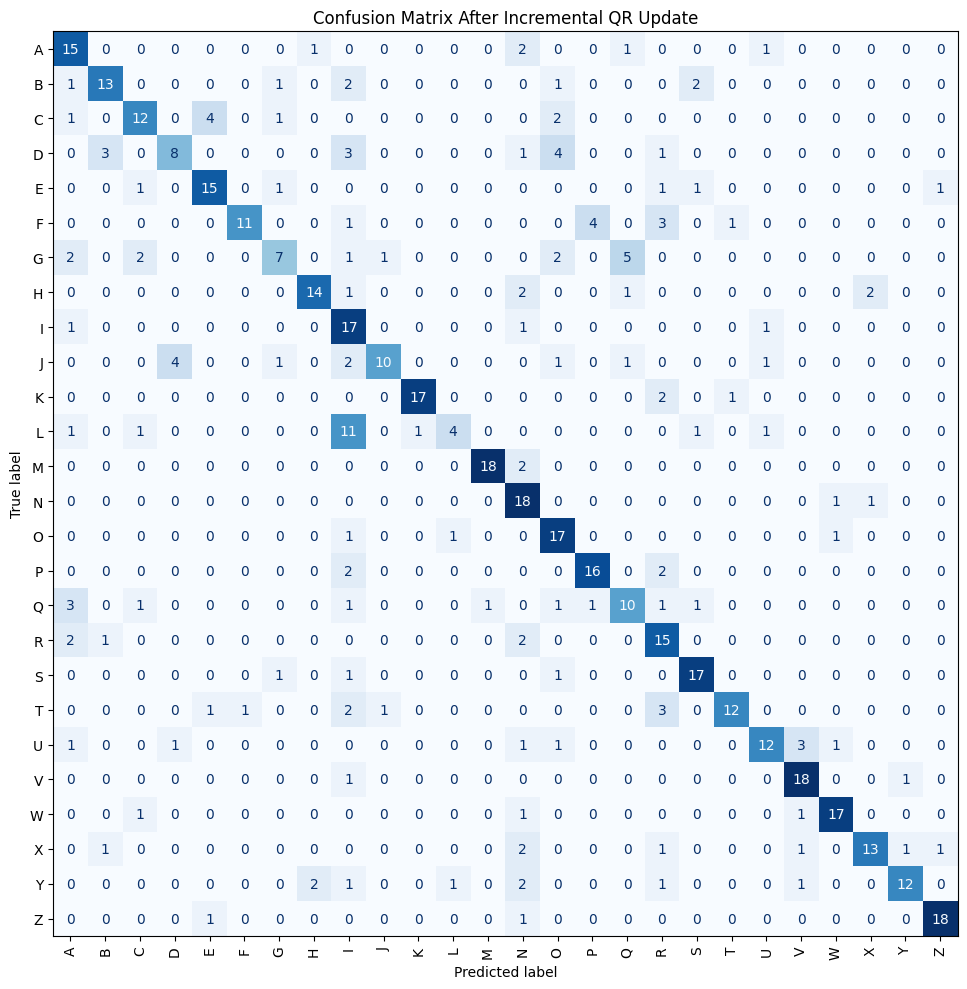


Classification report after update:
              precision    recall  f1-score   support

           A       0.56      0.75      0.64        20
           B       0.72      0.65      0.68        20
           C       0.67      0.60      0.63        20
           D       0.62      0.40      0.48        20
           E       0.71      0.75      0.73        20
           F       0.92      0.55      0.69        20
           G       0.58      0.35      0.44        20
           H       0.82      0.70      0.76        20
           I       0.36      0.85      0.51        20
           J       0.83      0.50      0.62        20
           K       0.94      0.85      0.89        20
           L       0.67      0.20      0.31        20
           M       0.95      0.90      0.92        20
           N       0.51      0.90      0.65        20
           O       0.57      0.85      0.68        20
           P       0.76      0.80      0.78        20
           Q       0.56      0.50      0.53 

In [15]:
cm = confusion_matrix(
    test_labels_np,
    predicted_labels_updated,
    labels=range(1, 27),
)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=letters,
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix After Incremental QR Update")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("\nClassification report after update:")
print(
    classification_report(
        test_labels_np,
        predicted_labels_updated,
        labels=range(1, 27),
        target_names=letters,
        zero_division=0,
    )
)


,Class,Before,After
0,A,0.75,0.75
1,B,0.70,0.65
2,C,0.65,0.60
3,D,0.40,0.40
4,E,0.75,0.75
5,F,0.50,0.55
6,G,0.55,0.35
7,H,0.65,0.70
8,I,0.85,0.85
9,J,0.60,0.50


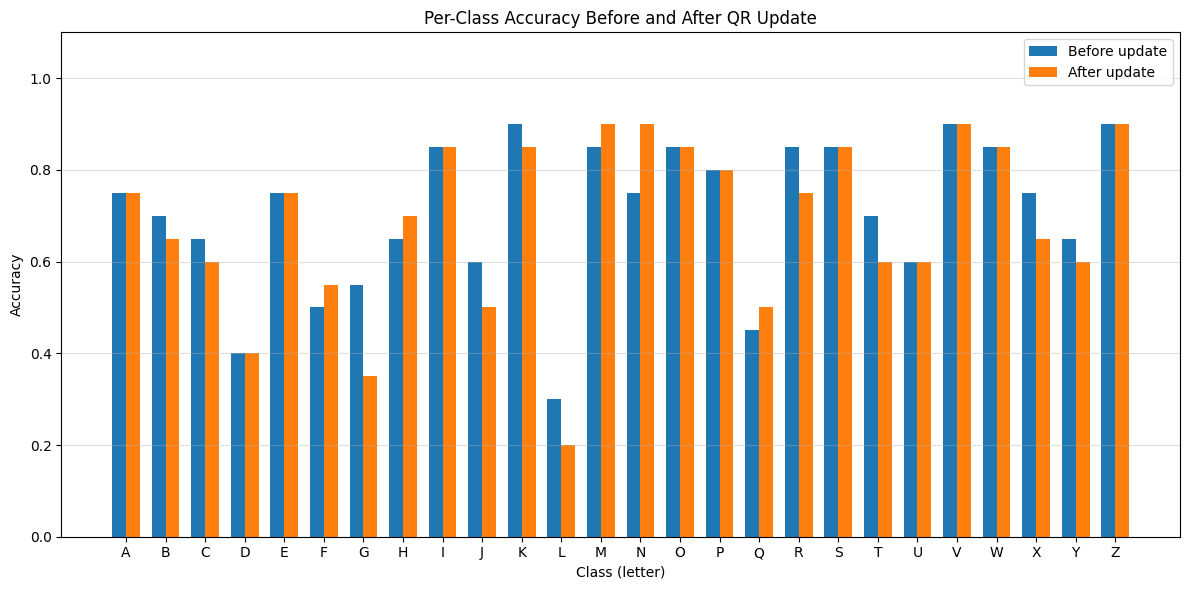

In [16]:
accuracy_per_class_before = {}
accuracy_per_class_after = {}

for label in range(1, 27):
    mask = test_labels_np == label

    accuracy_per_class_before[label] = np.mean(
        predicted_labels[mask] == label
    )
    accuracy_per_class_after[label] = np.mean(
        predicted_labels_updated[mask] == label
    )

comparison_df = pd.DataFrame(
    {
        "Class": letters,
        "Before": [
            accuracy_per_class_before[i] for i in range(1, 27)
        ],
        "After": [
            accuracy_per_class_after[i] for i in range(1, 27)
        ],
    }
)

display(comparison_df)

x = np.arange(len(letters))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(
    x - width / 2,
    comparison_df["Before"],
    width,
    label="Before update",
)
plt.bar(
    x + width / 2,
    comparison_df["After"],
    width,
    label="After update",
)
plt.xlabel("Class (letter)")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy Before and After QR Update")
plt.xticks(x, letters)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()


## 10. Limitations and reference

### Limitations

- The notebook explicitly forms a full \(784\times784\) matrix \(Q\) for every
  class. This is convenient for an educational implementation but memory-heavy.
  A factored or economy representation would be preferable for larger problems.
- The incremental routine is specialized to **appending columns at the end**
  and to the tall regime used here, where the number of training columns remains
  below the ambient dimension.
- Runtime measurements are implementation-dependent. Python loops around small
  Givens rotations should not be interpreted as a benchmark of an optimized
  LAPACK-style updating routine.
- The classification experiment alone does not establish a cause for any
  observed accuracy change after adding data.

### Primary numerical-linear-algebra reference

S. Hammarling and C. Lucas, **"Updating the QR Factorization and the Least
Squares Problem,"** MIMS EPrint 2008.111, Manchester Institute for Mathematical
Sciences, University of Manchester, 2008.

This notebook is an **educational adaptation**, not a line-for-line
implementation of the paper's LAPACK-style algorithms. The key Givens
convention and the relationship between updates to \(Q\) and \(R\) follow
Algorithm 1.1 and the column-addition development in Section 2.5.
